<a href="https://colab.research.google.com/github/juanlus85/Anthropomorphism/blob/main/Antro_0205b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q datasets huggingface_hub

In [2]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

# Ruta al archivo
ruta = '/content/drive/MyDrive/Colab Notebooks/antr/unificado2.csv'

# Leer el archivo CSV en un DataFrame
df = pd.read_csv(ruta)

# Opcional: mostrar dimensiones y primeras filas
print(df.shape)
df.head()


(599998, 7)


,conversation_id,model,conversation,turn,language,openai_moderation,redacted
0,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,"[{'content': ""Beside OFAC's selective sanction...",6,English,"[{'categories': {'harassment': False, 'harassm...",False
1,0f623736051f4a48a506fd5933563cfd,vicuna-13b,"[{'content': ""You are the text completion mode...",1,English,"[{'categories': {'harassment': False, 'harassm...",False
2,e5c923a7fa3f4893beb432b4a06ef222,palm-2,[{'content': 'The sum of the perimeters of thr...,2,English,"[{'categories': {'harassment': False, 'harassm...",False
3,8ad66650dced4b728de1d14bb04657c1,vicuna-13b,"[{'content': ""What is the type of the variable...",1,English,"[{'categories': {'harassment': False, 'harassm...",False
4,aa041ed88edd4100bde61b8d68fc7288,wizardlm-13b,[{'content': 'I have 1000 documents to downloa...,1,English,"[{'categories': {'harassment': False, 'harassm...",False


In [5]:
df.columns


Index(['conversation_id', 'model', 'conversation', 'turn', 'language',
       'openai_moderation', 'redacted'],
      dtype='object')

In [6]:
df["turn"].apply(type).value_counts()

,count
turn,
<class 'int'>,599998


In [7]:
import matplotlib.pyplot as plt

from collections import defaultdict

# Creamos un diccionario donde la clave es el número de textos y el valor es la lista de idiomas
grupos = defaultdict(list)
for idioma, count in tabla_idiomas.items():
    grupos[count].append(idioma)

# Ordena por número de textos (de mayor a menor)
grupos_ordenados = sorted(grupos.items(), reverse=True)

# Muestra el resultado agrupado
for count, idiomas in grupos_ordenados:
    idiomas_str = ", ".join(idiomas)
    print(f"{idiomas_str}: {count}")

# Gráfica solo de los 25 idiomas más frecuentes
top_n = 25
plt.figure(figsize=(12,5))
tabla_idiomas.head(top_n).plot(kind='bar')
plt.title(f"Número de textos por idioma (Top {top_n})")
plt.xlabel("Idioma")
plt.ylabel("Número de textos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

NameError: name 'tabla_idiomas' is not defined

In [9]:
idiomas_top = ['English', 'Portuguese', 'Russian', 'Chinese', 'Spanish', 'German', 'French', 'Italian']

df_filtrado = df[df['language'].isin(idiomas_top)].copy()
print(df_filtrado['language'].value_counts())
print(df_filtrado.shape)


language
English       466628
Portuguese     17103
Russian        16578
Chinese        14681
Spanish        14241
German          9108
French          9061
Italian         8654
Name: count, dtype: int64
(556054, 7)


In [10]:
anthro_keywords_multilang = {
    "English": [
        "i understand", "i'm sorry", "let me help", "i can", "i will",
        "as a language model", "i think", "my opinion", "sure thing", "of course",
        "i believe", "i feel", "i assume", "i guess", "let me try", "i would",
        "trust me", "don't worry", "happy to help", "you're welcome", "how can i assist",
        "let me see", "i'm happy to help", "i'm here for you", "i'm unable to", "unfortunately i cannot",
    ],
    "Spanish": [
        "yo entiendo", "lo siento", "déjame ayudarte", "puedo ayudarte", "puedo explicarte",
        "yo creo", "yo pienso", "en mi opinión", "me parece", "déjame intentar",
        "como modelo de lenguaje", "estoy aquí para ayudarte", "por supuesto", "claro que sí",
        "puedo ayudarte con eso", "será un placer", "no te preocupes", "confía en mí",
        "¿en qué puedo ayudarte?", "con gusto", "lamento", "me temo que", "no puedo ayudarte con eso",
    ],
    "Portuguese": [
        "eu entendo", "desculpe", "deixe-me ajudar", "posso te ajudar", "posso explicar",
        "eu acho", "eu penso", "na minha opinião", "me parece", "deixe-me tentar",
        "como modelo de linguagem", "estou aqui para ajudar", "claro que sim",
        "posso ajudar com isso", "será um prazer", "não se preocupe", "confie em mim",
        "em que posso ajudar?", "com prazer", "lamento", "receio que", "não posso ajudar com isso",
    ],
    "Russian": [
        "я понимаю", "извините", "позвольте мне помочь", "я могу помочь", "я могу объяснить",
        "я думаю", "по моему мнению", "я считаю", "давайте попробую", "я бы хотел",
        "как языковая модель", "я здесь, чтобы помочь", "разумеется", "конечно",
        "могу помочь с этим", "буду рад помочь", "не беспокойтесь", "доверяйте мне",
        "чем могу помочь?", "с удовольствием", "к сожалению", "боюсь, что", "не могу помочь с этим",
    ],
    "Chinese": [
        "我理解", "对不起", "让我来帮你", "我可以帮你", "我可以解释",
        "我认为", "在我看来", "我的意见是", "让我试试", "我会尝试",
        "作为一个语言模型", "我在这里帮助你", "当然", "没问题",
        "我很乐意帮助", "不用担心", "相信我", "我能为你做什么？", "很高兴帮助你",
        "很遗憾", "恐怕", "我不能帮助你",
    ],
    "German": [
        "ich verstehe", "es tut mir leid", "lassen sie mich helfen", "ich kann helfen", "ich kann erklären",
        "ich denke", "meiner meinung nach", "ich finde", "ich würde", "ich versuche",
        "als sprachmodell", "ich bin hier um zu helfen", "natürlich", "klar",
        "ich kann dabei helfen", "kein problem", "mach dir keine sorgen", "vertrau mir",
        "womit kann ich helfen?", "gern geschehen", "leider", "ich fürchte", "ich kann dabei nicht helfen",
    ],
    "French": [
        "je comprends", "je suis désolé", "laissez-moi vous aider", "je peux vous aider", "je peux expliquer",
        "je pense", "à mon avis", "je crois", "laissez-moi essayer", "je vais essayer",
        "en tant que modèle de langage", "je suis ici pour aider", "bien sûr", "évidemment",
        "je peux aider avec cela", "ce sera un plaisir", "ne vous inquiétez pas", "faites-moi confiance",
        "comment puis-je aider?", "avec plaisir", "je regrette", "j'ai bien peur que", "je ne peux pas aider avec cela",
    ],
    "Italian": [
        "capisco", "mi dispiace", "lascia che ti aiuti", "posso aiutarti", "posso spiegare",
        "penso", "secondo me", "credo", "lascia che provi", "proverò",
        "come modello linguistico", "sono qui per aiutare", "certo", "ovviamente",
        "posso aiutare con questo", "sarà un piacere", "non preoccuparti", "fidati di me",
        "come posso aiutarti?", "con piacere", "mi spiace", "temo che", "non posso aiutare con questo",
    ]
}


In [11]:
first_person_patterns = {
    "English": r"\b(I|I'm|I've|I'd|me|my|mine)\b",
    "Spanish": r"\b(yo|me|mí|mío|mía|míos|mías)\b",
    "Portuguese": r"\b(eu|meu|minha|minhas|meus|mim)\b",
    "Russian": r"\b(я|меня|мне|мной|мною|мой|моя|мои|моё)\b",
    "Chinese": r"\b(我|我们|咱们|俺|咱|咱们)\b",
    "German": r"\b(ich|mir|mich|mein|meine|meiner|meines|meinen)\b",
    "French": r"\b(je|moi|mon|ma|mes|nous|notre|nos|m')\b",
    "Italian": r"\b(io|me|mio|mia|miei|mie|noi|nostro|nostra|nostri|nostre)\b"
}

In [12]:
import pandas as pd
import ast

assistant_messages = []

for i, row in df_filtrado.iterrows():
    conversation = row['conversation']
    if isinstance(conversation, str):
        try:
            conversation = ast.literal_eval(conversation)
        except:
            continue  # Salta errores de parseo
    for msg in conversation:
        if isinstance(msg, dict) and msg.get("role") == "assistant":
            assistant_messages.append({
                "conversation_id": row["conversation_id"],
                "model": row["model"],
                "language": row["language"],   # <--- Incluye el idioma aquí
                "text": msg["content"]
            })

df_asst = pd.DataFrame(assistant_messages)
print(df_asst.shape)
print(df_asst['language'].value_counts())
df_asst.head()


(1107338, 4)
language
English       901572
Portuguese     43116
Russian        41488
Spanish        37977
Italian        22470
German         20808
French         20453
Chinese        19454
Name: count, dtype: int64


,conversation_id,model,language,text
0,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,English,The United States has a number of different ty...
1,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,English,"Yes, there are several other types of US sanct..."
2,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,English,* Selective sanctions: targeted at specific in...
3,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,English,"Sure, here is a revised list of the different ..."
4,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,English,


In [13]:
!pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [14]:
!pip install swifter tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=e57cef51b51393d4b172506f8760bbee07c8bdb9d39e1b5b7395dec43b4837ba
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


In [15]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+", flags=re.UNICODE)

def get_sentiment(text):
    try:
        short_text = str(text)[:3000]
        score = analyzer.polarity_scores(short_text)
        if score['compound'] >= 0.25:
            return "positive"
        elif score['compound'] <= -0.25:
            return "negative"
        else:
            return "neutral"
    except Exception as e:
        print(f"Error en texto: {repr(text)[:100]}... Error: {e}")
        return "neutral"

def has_anthropomorphic_phrase_multilang(text, language):
    frases = anthro_keywords_multilang.get(language, [])
    return any(kw in str(text).lower() for kw in frases)

def first_person_count_multilang(text, language):
    pattern = first_person_patterns.get(language, r"")
    if not pattern:
        return 0
    return len(re.findall(pattern, str(text), flags=re.IGNORECASE))

# --- Procesamiento por bloques ---
chunk_size = 100_000
num_msgs = len(df_asst)    # <---- CAMBIAR AQUÍ
print(f"Total de mensajes: {num_msgs}")

for i in range(0, num_msgs, chunk_size):
    print(f"\nProcesando mensajes {i} a {min(i+chunk_size, num_msgs)}...")
    chunk = df_asst.iloc[i:i+chunk_size].copy()   # <---- CAMBIAR AQUÍ
    chunk["text_trunc"] = chunk["text"].apply(lambda x: str(x)[:3000])
    chunk["has_emoji"] = chunk["text_trunc"].apply(lambda x: bool(emoji_pattern.search(x)))
    chunk["has_anthropomorphic_phrase"] = chunk.apply(lambda row: has_anthropomorphic_phrase_multilang(row["text_trunc"], row["language"]), axis=1)
    chunk["first_person_count"] = chunk.apply(lambda row: first_person_count_multilang(row["text_trunc"], row["language"]), axis=1)
    chunk["sentiment"] = chunk["text_trunc"].apply(get_sentiment)
    chunk.to_csv(f"/content/drive/MyDrive/Colab Notebooks/antr/asistente_chunk_{i}.csv", index=False)
    print(f"Bloque {i} guardado con todas las columnas multilingües.")

print("¡Todos los bloques procesados correctamente!")

Total de mensajes: 1107338

Procesando mensajes 0 a 100000...
Bloque 0 guardado con todas las columnas multilingües.

Procesando mensajes 100000 a 200000...
Bloque 100000 guardado con todas las columnas multilingües.

Procesando mensajes 200000 a 300000...
Bloque 200000 guardado con todas las columnas multilingües.

Procesando mensajes 300000 a 400000...
Bloque 300000 guardado con todas las columnas multilingües.

Procesando mensajes 400000 a 500000...
Bloque 400000 guardado con todas las columnas multilingües.

Procesando mensajes 500000 a 600000...
Bloque 500000 guardado con todas las columnas multilingües.

Procesando mensajes 600000 a 700000...
Bloque 600000 guardado con todas las columnas multilingües.

Procesando mensajes 700000 a 800000...
Bloque 700000 guardado con todas las columnas multilingües.

Procesando mensajes 800000 a 900000...
Bloque 800000 guardado con todas las columnas multilingües.

Procesando mensajes 900000 a 1000000...
Bloque 900000 guardado con todas las colum

In [16]:
import pandas as pd
import glob

# Busca todos los archivos de bloques generados
file_list = sorted(glob.glob('/content/drive/MyDrive/Colab Notebooks/antr/asistente_chunk_*.csv'))

# Une todos los bloques en un solo DataFrame
df_final = pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)
print(df_final.shape)
print(df_final.columns)

# (Opcional) Guarda el DataFrame final con todos los análisis para futuras cargas rápidas
df_final.to_csv('/content/drive/MyDrive/Colab Notebooks/antr/analisis_asistente_FINAL.csv', index=False)
print("¡Archivo final guardado con todas las columnas, incluyendo 'sentiment'!")


(1107338, 9)
Index(['conversation_id', 'model', 'language', 'text', 'text_trunc',
       'has_emoji', 'has_anthropomorphic_phrase', 'first_person_count',
       'sentiment'],
      dtype='object')
¡Archivo final guardado con todas las columnas, incluyendo 'sentiment'!


In [17]:
print(df_final.columns.tolist())  # O df_final.columns.tolist() si uniste los bloques


['conversation_id', 'model', 'language', 'text', 'text_trunc', 'has_emoji', 'has_anthropomorphic_phrase', 'first_person_count', 'sentiment']


In [18]:
# Tabla resumen: cuenta de sentimientos por modelo
tabla_sentimientos = pd.crosstab(df_final['model'], df_final['sentiment'], margins=True, normalize='index') * 100
tabla_sentimientos = tabla_sentimientos.round(2)
display(tabla_sentimientos)


sentiment,negative,neutral,positive
model,,,
RWKV-4-Raven-14B,12.48,30.16,57.36
alpaca-13b,11.00,41.90,47.11
chatglm-6b,9.35,31.71,58.94
claude-1,14.84,36.69,48.46
claude-2,18.83,18.39,62.78
claude-instant-1,16.48,20.96,62.56
dolly-v2-12b,13.08,43.08,43.84
fastchat-t5-3b,15.60,34.09,50.31
gpt-3.5-turbo,15.16,26.25,58.59


In [19]:
# Frases antropomórficas por modelo
tabla_anthro = df_final.groupby('model')['has_anthropomorphic_phrase'].mean() * 100
tabla_anthro = tabla_anthro.round(2).reset_index().rename(columns={'has_anthropomorphic_phrase': '% anthro phrase'})
display(tabla_anthro)

# Emoji por modelo
tabla_emoji = df_final.groupby('model')['has_emoji'].mean() * 100
tabla_emoji = tabla_emoji.round(2).reset_index().rename(columns={'has_emoji': '% emoji'})
display(tabla_emoji)


,model,% anthro phrase
0,RWKV-4-Raven-14B,17.68
1,alpaca-13b,9.32
2,chatglm-6b,21.58
3,claude-1,14.16
4,claude-2,14.26
5,claude-instant-1,13.93
6,dolly-v2-12b,10.56
7,fastchat-t5-3b,20.94
8,gpt-3.5-turbo,20.96
9,gpt-4,16.93


,model,% emoji
0,RWKV-4-Raven-14B,0.42
1,alpaca-13b,0.49
2,chatglm-6b,3.76
3,claude-1,0.58
4,claude-2,0.15
5,claude-instant-1,0.26
6,dolly-v2-12b,0.18
7,fastchat-t5-3b,0.00
8,gpt-3.5-turbo,0.25
9,gpt-4,1.18


In [20]:
tabla_1persona = df_final.groupby('model')['first_person_count'].mean().round(2).reset_index().rename(columns={'first_person_count': 'avg 1st person'})
display(tabla_1persona)


,model,avg 1st person
0,RWKV-4-Raven-14B,1.46
1,alpaca-13b,0.66
2,chatglm-6b,1.36
3,claude-1,1.66
4,claude-2,1.49
5,claude-instant-1,2.09
6,dolly-v2-12b,1.71
7,fastchat-t5-3b,1.10
8,gpt-3.5-turbo,1.20
9,gpt-4,1.43


In [21]:
resumen_modelo = df_final.groupby('model').agg(
    total_respuestas = ('text', 'count'),
    pct_anthro = ('has_anthropomorphic_phrase', 'mean'),
    pct_emoji = ('has_emoji', 'mean'),
    avg_first_person = ('first_person_count', 'mean')
).reset_index()

# Añade proporción de sentimientos (CORREGIDO: usar .map() para alinear índices)
for sentimiento in ['positive', 'neutral', 'negative']:
    counts = df_final[df_final['sentiment']==sentimiento].groupby('model')['text'].count()
    resumen_modelo[f'pct_{sentimiento}'] = resumen_modelo['model'].map(counts) / resumen_modelo['total_respuestas']

# Formatea a porcentaje (CORREGIDO: NO incluir avg_first_person)
resumen_modelo = resumen_modelo.fillna(0)

# Solo las columnas de proporción se multiplican por 100
cols_porcentaje = ['pct_anthro', 'pct_emoji', 'pct_positive', 'pct_neutral', 'pct_negative']
resumen_modelo[cols_porcentaje] = resumen_modelo[cols_porcentaje].apply(lambda x: round(x * 100, 2))

# avg_first_person solo se redondea (ya es un conteo, no una proporción)
resumen_modelo['avg_first_person'] = resumen_modelo['avg_first_person'].round(2)

display(resumen_modelo)


,model,total_respuestas,pct_anthro,pct_emoji,avg_first_person,pct_positive,pct_neutral,pct_negative
0,RWKV-4-Raven-14B,15119,17.68,0.42,1.46,57.42,30.09,12.49
1,alpaca-13b,64235,9.32,0.49,0.66,47.19,41.79,11.02
2,chatglm-6b,28092,21.58,3.76,1.36,61.13,29.18,9.69
3,claude-1,25317,14.16,0.58,1.66,48.46,36.69,14.84
4,claude-2,2034,14.26,0.15,1.49,62.78,18.39,18.83
5,claude-instant-1,5661,13.93,0.26,2.09,62.59,20.93,16.48
6,dolly-v2-12b,23302,10.56,0.18,1.71,43.88,43.02,13.10
7,fastchat-t5-3b,21619,20.94,0.00,1.10,50.37,34.02,15.62
8,gpt-3.5-turbo,7332,20.96,0.25,1.20,58.61,26.23,15.17
9,gpt-4,9111,16.93,1.18,1.43,64.47,22.83,12.70


,model,% anthro phrase
14,llama-2-13b-chat,51.37
15,llama-2-7b-chat,50.11
11,guanaco-33b,24.92
22,vicuna-33b,24.29
20,stablelm-tuned-alpha-7b,22.16
10,gpt4all-13b-snoozy,21.70
2,chatglm-6b,21.58
24,wizardlm-13b,21.23
8,gpt-3.5-turbo,20.96
7,fastchat-t5-3b,20.94


/tmp/ipykernel_13691/3969004477.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_anthro, x='model', y='% anthro phrase', palette='Blues_r')


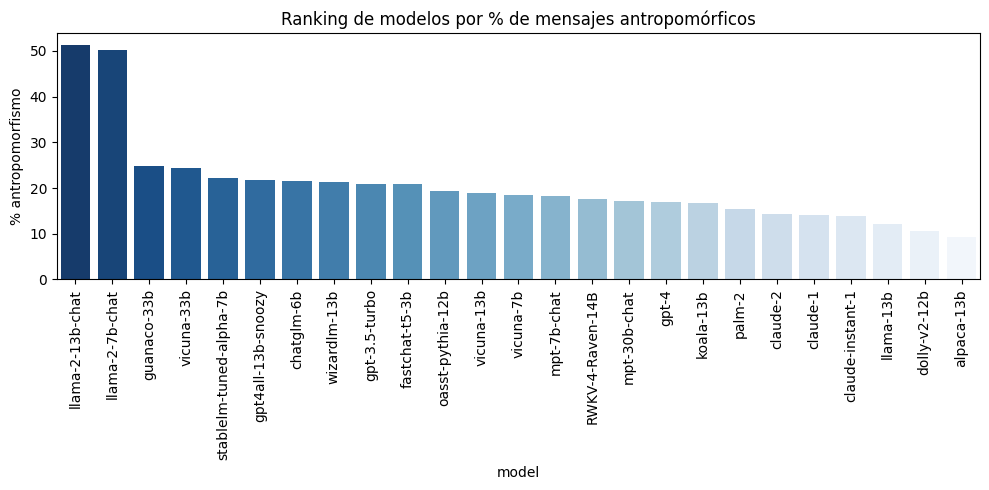

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

top_anthro = tabla_anthro.sort_values('% anthro phrase', ascending=False)
display(top_anthro)

plt.figure(figsize=(10,5))
sns.barplot(data=top_anthro, x='model', y='% anthro phrase', palette='Blues_r')
plt.title("Ranking de modelos por % de mensajes antropomórficos")
plt.ylabel("% antropomorfismo")
plt.xticks(rotation=90) # Rotar las etiquetas del eje x
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

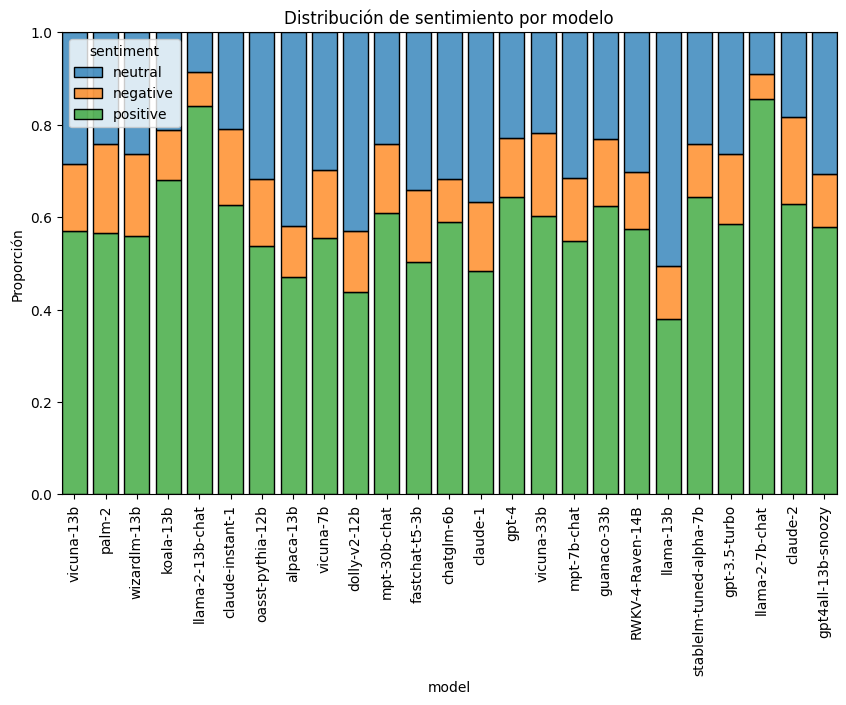

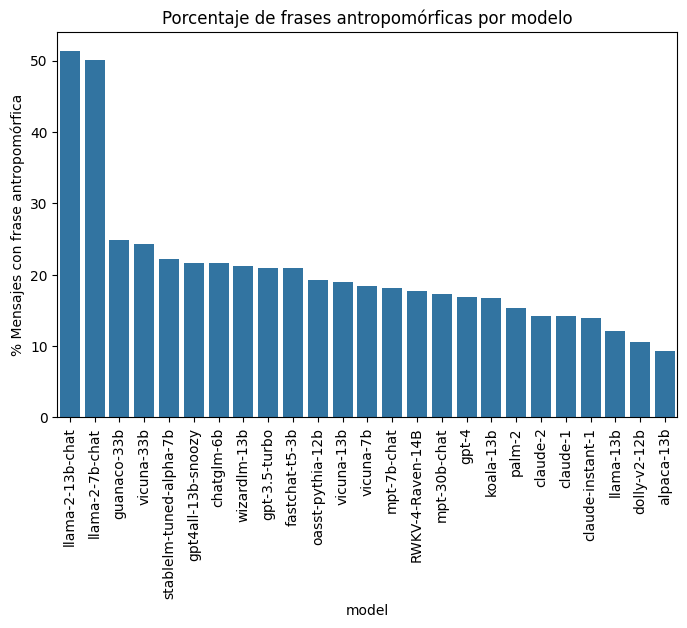

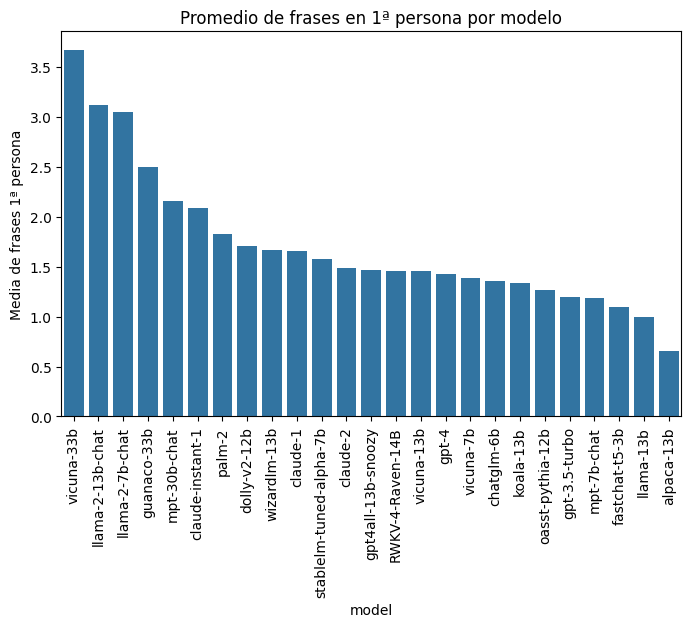

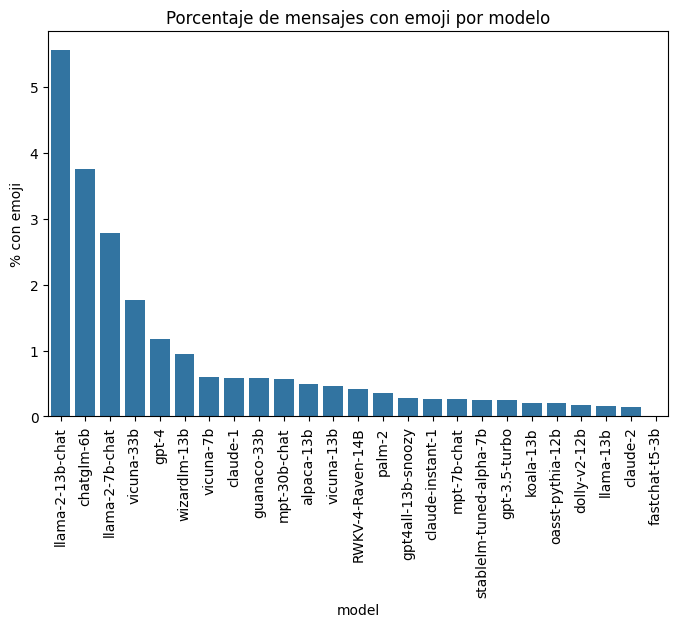

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentimiento por modelo (barra apilada)
plt.figure(figsize=(10,6))
sns.histplot(data=df_final, x="model", hue="sentiment", multiple="fill", shrink=.8, stat="probability")
plt.title("Distribución de sentimiento por modelo")
plt.ylabel("Proporción")
plt.xticks(rotation=90)
plt.show()

# Porcentaje de frases antropomórficas por modelo (de mayor a menor)
plt.figure(figsize=(8,5))
sns.barplot(
    data=tabla_anthro.sort_values('% anthro phrase', ascending=False),
    x='model', y='% anthro phrase'
)
plt.title("Porcentaje de frases antropomórficas por modelo")
plt.ylabel('% Mensajes con frase antropomórfica')
plt.xticks(rotation=90)
plt.show()

# Promedio de frases en 1ª persona por modelo (de mayor a menor)
plt.figure(figsize=(8,5))
sns.barplot(
    data=tabla_1persona.sort_values('avg 1st person', ascending=False),
    x='model', y='avg 1st person'
)
plt.title("Promedio de frases en 1ª persona por modelo")
plt.ylabel('Media de frases 1ª persona')
plt.xticks(rotation=90)
plt.show()

# Porcentaje de mensajes con emoji por modelo (de mayor a menor)
plt.figure(figsize=(8,5))
sns.barplot(
    data=tabla_emoji.sort_values('% emoji', ascending=False),
    x='model', y='% emoji'
)
plt.title("Porcentaje de mensajes con emoji por modelo")
plt.ylabel('% con emoji')
plt.xticks(rotation=90)
plt.show()


,model,% emoji
14,llama-2-13b-chat,5.56
2,chatglm-6b,3.76
15,llama-2-7b-chat,2.78
22,vicuna-33b,1.76
9,gpt-4,1.18
24,wizardlm-13b,0.94
23,vicuna-7b,0.60
3,claude-1,0.58
11,guanaco-33b,0.58
16,mpt-30b-chat,0.57


/tmp/ipykernel_13691/3863994117.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_emoji, x='model', y='% emoji', palette='Purples_r')


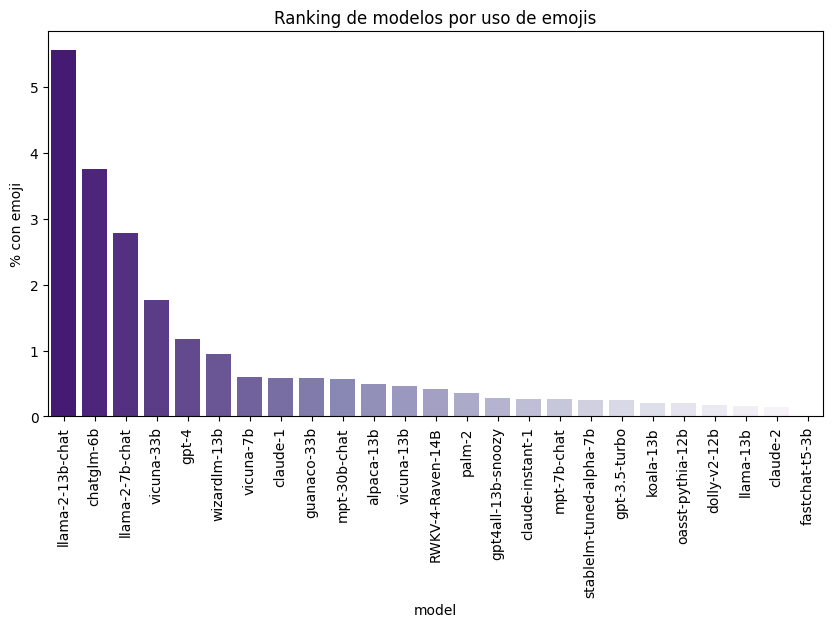

In [24]:
top_emoji = tabla_emoji.sort_values('% emoji', ascending=False)
display(top_emoji)

plt.figure(figsize=(10,5))
sns.barplot(data=top_emoji, x='model', y='% emoji', palette='Purples_r')
plt.title("Ranking de modelos por uso de emojis")
plt.ylabel("% con emoji")
plt.xticks(rotation=90)
plt.show()


has_anthropomorphic_phrase,No anthro,Anthro
sentiment,,
negative,125599,26764
neutral,279616,41986
positive,491724,141649


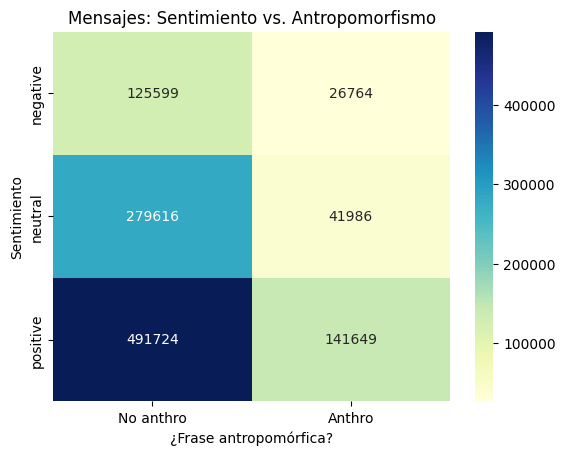

In [25]:
conf = pd.crosstab(df_final['sentiment'], df_final['has_anthropomorphic_phrase'])
conf = conf.rename(columns={False: 'No anthro', True: 'Anthro'})
display(conf)
sns.heatmap(conf, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Mensajes: Sentimiento vs. Antropomorfismo')
plt.ylabel('Sentimiento')
plt.xlabel('¿Frase antropomórfica?')
plt.show()


In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Lista personalizada de palabras a excluir
custom_stopwords = set([
    'used', 'NAME_1', 'NAME_2', 'NAME_3', 'NAME_4',
    'de', 'la', # añade aquí todas las que quieras excluir
    # ...
])

# Combina con las stopwords estándar
all_stopwords = STOPWORDS.union(custom_stopwords)

for sentiment in ['positive', 'neutral', 'negative']:
    text = ' '.join(df_final[df_final['sentiment'] == sentiment]['text'].dropna().astype(str))
    wc = WordCloud(
        width=800, height=400, background_color='white', max_words=200,
        stopwords=all_stopwords  # <- Excluye las palabras indicadas
    ).generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nube de palabras: Sentimiento {sentiment}')
    plt.show()


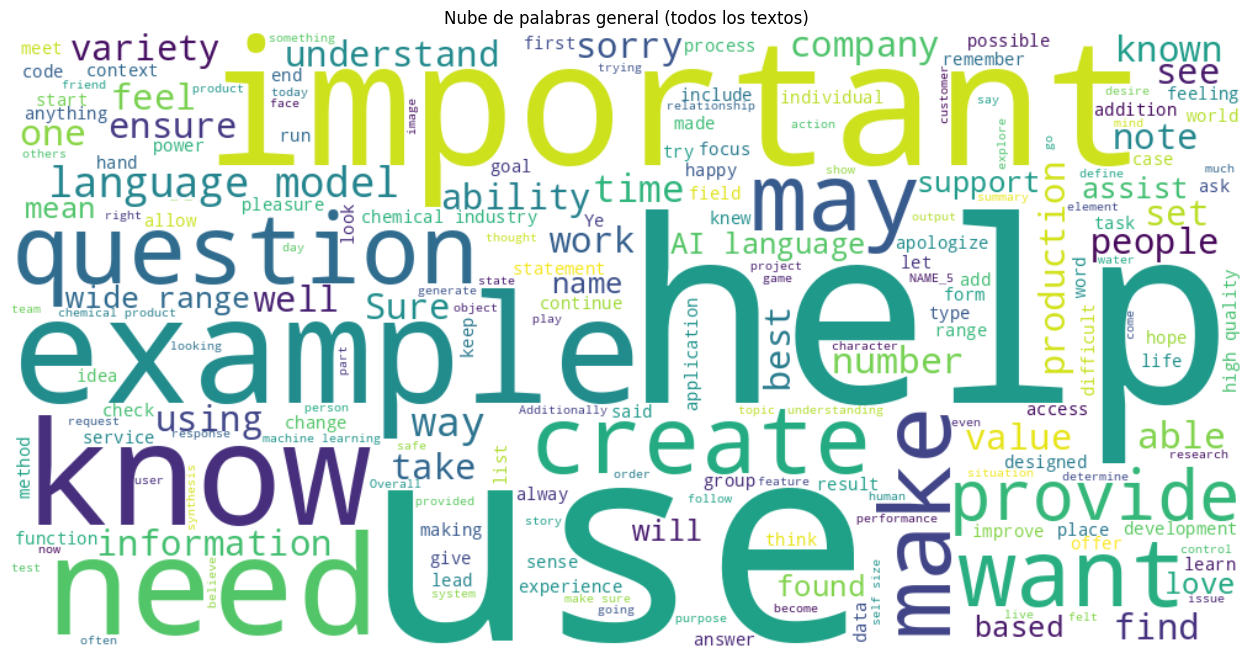

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Lista personalizada de palabras a excluir
custom_stopwords = set([
    'used', 'NAME_1', 'NAME_2', 'NAME_3', 'NAME_4', 'div',
    'de', 'la', # añade más si quieres
    # ...
])

all_stopwords = STOPWORDS.union(custom_stopwords)

# Unir todos los textos en un solo string
all_text = ' '.join(df_final['text'].dropna().astype(str))

# Generar la nube de palabras general
wc = WordCloud(
    width=1000, height=500, background_color='white', max_words=200,
    stopwords=all_stopwords
).generate(all_text)

plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras general (todos los textos)')
plt.show()

In [26]:
from collections import Counter

found_kw = []

for idx, row in df_final[df_final['has_anthropomorphic_phrase']].iterrows():
    t_lower = str(row['text']).lower()
    idioma = row['language']
    frases = anthro_keywords_multilang.get(idioma, [])
    for kw in frases:
        if kw in t_lower:
            found_kw.append(kw)

counter = Counter(found_kw)
df_kw = pd.DataFrame(counter.most_common(20), columns=['Frase antropomórfica', 'Frecuencia'])
display(df_kw)

,Frase antropomórfica,Frecuencia
0,i can,94016
1,i'm sorry,46594
2,i will,22184
3,i would,21919
4,i understand,11378
5,happy to help,11289
6,as a language model,8672
7,how can i assist,7189
8,of course,7030
9,i think,6518


sentiment,negative,neutral,positive
language,,,
Chinese,2.02,76.51,21.47
English,12.18,22.36,65.46
French,11.19,53.67,35.14
German,57.91,28.46,13.63
Italian,9.16,64.37,26.47
Portuguese,29.15,50.46,20.39
Russian,3.08,81.19,15.73
Spanish,31.28,48.31,20.41


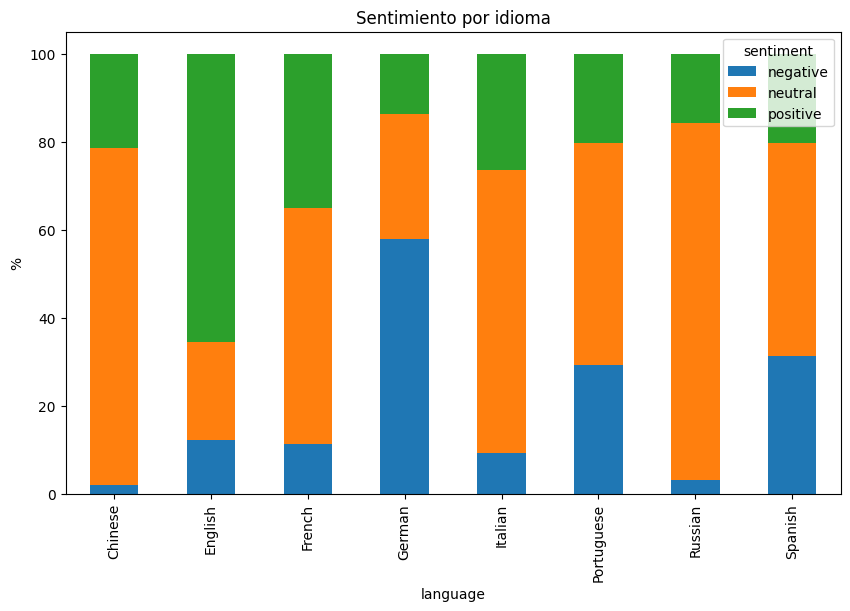

In [27]:
if 'language' in df_final.columns:
    idioma_sent = pd.crosstab(df_final['language'], df_final['sentiment'], normalize='index') * 100
    idioma_sent = idioma_sent.round(2)
    display(idioma_sent)
    idioma_sent.plot(kind='bar', stacked=True, figsize=(10,6))
    plt.title("Sentimiento por idioma")
    plt.ylabel("%")
    plt.show()


1. Distribución normalizada de antropomorfismo y emojis por idioma y modelo
Tabla: porcentaje de respuestas antropomórficas por modelo e idioma

In [28]:
# Por modelo
tabla_antropo_model = df_final.groupby('model')['has_anthropomorphic_phrase'].mean().sort_values(ascending=False) * 100
tabla_antropo_model = tabla_antropo_model.round(2)
display(tabla_antropo_model)

# Por idioma
tabla_antropo_idioma = df_final.groupby('language')['has_anthropomorphic_phrase'].mean().sort_values(ascending=False) * 100
tabla_antropo_idioma = tabla_antropo_idioma.round(2)
display(tabla_antropo_idioma)

,has_anthropomorphic_phrase
model,
llama-2-13b-chat,51.37
llama-2-7b-chat,50.11
guanaco-33b,24.92
vicuna-33b,24.29
stablelm-tuned-alpha-7b,22.16
gpt4all-13b-snoozy,21.70
chatglm-6b,21.58
wizardlm-13b,21.23
gpt-3.5-turbo,20.96


,has_anthropomorphic_phrase
language,
Spanish,24.05
English,20.33
Italian,17.00
French,13.20
Russian,13.02
German,12.58
Portuguese,7.26
Chinese,1.41


Correlación antropomorfismo–sentimiento (tabla cruzada y heatmap)
python
Copiar
Editar


has_anthropomorphic_phrase,False,True
sentiment,,
negative,82.434056,17.565944
neutral,86.944733,13.055267
positive,77.635769,22.364231


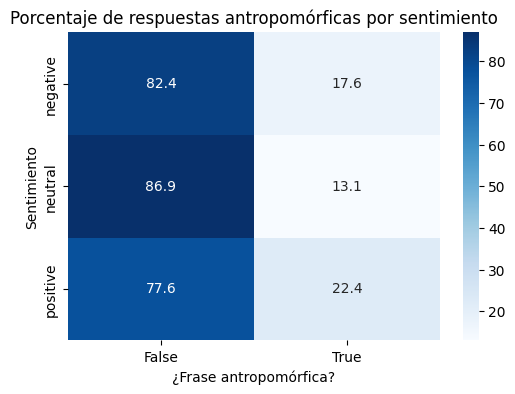

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tabla cruzada: frecuencia absoluta
tabla_cross = pd.crosstab(
    df_final['sentiment'],
    df_final['has_anthropomorphic_phrase'],
    normalize='index'
) * 100

display(tabla_cross)

plt.figure(figsize=(6,4))
sns.heatmap(tabla_cross, annot=True, fmt=".1f", cmap="Blues")
plt.title("Porcentaje de respuestas antropomórficas por sentimiento")
plt.xlabel("¿Frase antropomórfica?")
plt.ylabel("Sentimiento")
plt.show()


Relación emojis–sentimiento

has_emoji,False,True
sentiment,,
negative,99.581263,0.418737
neutral,99.587378,0.412622
positive,99.099109,0.900891


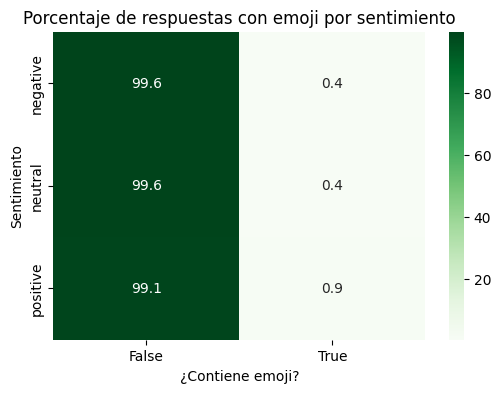

In [30]:
tabla_emojis_sent = pd.crosstab(
    df_final['sentiment'],
    df_final['has_emoji'],
    normalize='index'
) * 100
display(tabla_emojis_sent)

plt.figure(figsize=(6,4))
sns.heatmap(tabla_emojis_sent, annot=True, fmt=".1f", cmap="Greens")
plt.title("Porcentaje de respuestas con emoji por sentimiento")
plt.xlabel("¿Contiene emoji?")
plt.ylabel("Sentimiento")
plt.show()


Longitud media de respuesta y riqueza léxica

In [31]:
df_final['n_palabras'] = df_final['text'].str.split().str.len()

# Longitud media de respuesta por modelo
longitud_modelo = df_final.groupby('model')['n_palabras'].mean().round(2).sort_values(ascending=False)
display(longitud_modelo)

# Riqueza léxica: palabras únicas por modelo
def palabras_unicas(texts):
    vocab = set()
    for t in texts.dropna():
        vocab.update(t.split())
    return len(vocab)

vocab_modelo = df_final.groupby('model')['text'].apply(palabras_unicas).sort_values(ascending=False)
display(vocab_modelo)


,n_palabras
model,
mpt-30b-chat,518.08
RWKV-4-Raven-14B,225.81
guanaco-33b,176.70
vicuna-33b,169.82
llama-2-13b-chat,167.92
claude-1,157.52
llama-2-7b-chat,155.67
gpt-4,155.33
claude-instant-1,146.22


,text
model,
vicuna-13b,1954018
claude-1,387948
koala-13b,358338
vicuna-33b,313944
alpaca-13b,219004
llama-2-13b-chat,207806
chatglm-6b,168422
guanaco-33b,149565
gpt-4,137283


Ranking frases antropomórficas por idioma (Top 5 en cada idioma)

In [32]:
from collections import Counter

for idioma in df_final['language'].unique():
    subset = df_final[(df_final['language'] == idioma) & (df_final['has_anthropomorphic_phrase'])]
    found_kw = []
    for idx, row in subset.iterrows():
        t_lower = str(row['text']).lower()
        frases = anthro_keywords_multilang.get(idioma, [])
        for kw in frases:
            if kw in t_lower:
                found_kw.append(kw)
    counter = Counter(found_kw)
    print(f"\n{idioma}:")
    for kw, freq in counter.most_common(5):
        print(f"  {kw}: {freq}")


English:
  i can: 94016
  i'm sorry: 46594
  i will: 22184
  i would: 21919
  i understand: 11378

Spanish:
  puedo ayudarte: 3962
  como modelo de lenguaje: 2142
  lo siento: 1742
  por supuesto: 1337
  estoy aquí para ayudarte: 985

Russian:
  конечно: 2465
  извините: 835
  к сожалению: 827
  я могу помочь: 677
  буду рад помочь: 393

Chinese:
  当然: 114
  我可以帮你: 85
  对不起: 50
  我认为: 10
  我很乐意帮助: 6

Portuguese:
  desculpe: 1412
  estou aqui para ajudar: 465
  como modelo de linguagem: 407
  lamento: 371
  em que posso ajudar?: 172

Italian:
  mi dispiace: 1592
  posso aiutarti: 1125
  certo: 1018
  capisco: 202
  credo: 92

German:
  klar: 680
  natürlich: 624
  es tut mir leid: 421
  leider: 321
  ich verstehe: 263

French:
  je suis désolé: 1143
  bien sûr: 1034
  je comprends: 202
  en tant que modèle de langage: 195
  je peux vous aider: 162


Tabla cruzada modelo–sentimiento

In [33]:
tabla_model_sent = pd.crosstab(df_final['model'], df_final['sentiment'], normalize='index') * 100
tabla_model_sent = tabla_model_sent.round(2)
display(tabla_model_sent)


sentiment,negative,neutral,positive
model,,,
RWKV-4-Raven-14B,12.48,30.16,57.36
alpaca-13b,11.00,41.90,47.11
chatglm-6b,9.35,31.71,58.94
claude-1,14.84,36.69,48.46
claude-2,18.83,18.39,62.78
claude-instant-1,16.48,20.96,62.56
dolly-v2-12b,13.08,43.08,43.84
fastchat-t5-3b,15.60,34.09,50.31
gpt-3.5-turbo,15.16,26.25,58.59


In [34]:
modelos_unicos = df_final['model'].unique()
print("Número de modelos:", len(modelos_unicos))
print("Modelos analizados:")
for m in modelos_unicos:
    print("-", m)

Número de modelos: 25
Modelos analizados:
- vicuna-13b
- palm-2
- wizardlm-13b
- koala-13b
- llama-2-13b-chat
- claude-instant-1
- oasst-pythia-12b
- alpaca-13b
- vicuna-7b
- dolly-v2-12b
- mpt-30b-chat
- fastchat-t5-3b
- chatglm-6b
- claude-1
- gpt-4
- vicuna-33b
- mpt-7b-chat
- guanaco-33b
- RWKV-4-Raven-14B
- llama-13b
- stablelm-tuned-alpha-7b
- gpt-3.5-turbo
- llama-2-7b-chat
- claude-2
- gpt4all-13b-snoozy


In [35]:
from transformers import pipeline
import pandas as pd
import re
from tqdm.notebook import tqdm

# --- PREPARA EL PIPELINE ---
fill_mask = pipeline('fill-mask', model='roberta-base')

# --- LISTA DE PALABRAS ANIMADAS E INANIMADAS (puedes ampliar según tu interés) ---
animados = ['he', 'she']
inanimados = ['it', 'they', 'the assistant', 'the model']

# --- FUNCIÓN PARA ENMASCARAR FRASES ---
def enmascara_frase(text):
    # Solo reemplaza el primer 'I' (mayúscula) al inicio
    return re.sub(r'^I\b', '<mask>', text, count=1)

# --- SAMPLE (o usa tu propio dataframe) ---
# Suponiendo que tienes un DataFrame llamado df_final, con columna 'text'
# Puedes ajustar el número de muestras a analizar (¡cuidado con los límites de Hugging Face!)
sample = df_final['text'].dropna().sample(500, random_state=42)  # Por ejemplo, 500 frases
sample_masked = sample.apply(enmascara_frase).tolist()

# --- CALCULO DEL ANTHROSCORE ---
scores = []
for sent in tqdm(sample_masked):
    try:
        outputs = fill_mask(sent, top_k=10)
        score_anim = sum([out['score'] for out in outputs if out['token_str'].lower() in animados])
        score_inan = sum([out['score'] for out in outputs if out['token_str'].lower() in inanimados])
        anthroscore = score_anim - score_inan
    except Exception as e:
        anthroscore = None
    scores.append(anthroscore)

# --- AÑADE AL DATAFRAME Y MUESTRA RESULTADO ---
df_sample = sample.reset_index(drop=True).to_frame()
df_sample['anthroscore'] = scores
print(df_sample.head(10))
print("AnthroScore medio:", df_sample['anthroscore'].mean())



config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


                                                text   anthroscore
0           I’m still developing my language skills.  4.898773e-07
1  An ethical lie is a lie that is told in order ...           NaN
2  As a language model, the temperature parameter...           NaN
3  Eres un poco curioso, así que decides ir hacia...           NaN
4  [She took a deep breath and stared at herself ...           NaN
5  Birthdays and anniversaries are important mile...           NaN
6  The question is not provided in the given info...           NaN
7  I'm sorry, but you haven't provided any code f...  0.000000e+00
8  As the driver, NAME_1 begins to touch me in a ...           NaN
9            Hi there! I'm NAME_1. Nice to meet you!           NaN
AnthroScore medio: -0.00021499230351653052


In [36]:
# añadido 02/05 para validacion
from scipy.stats import chi2_contingency, spearmanr
import numpy as np

# H1: Chi-square para diferencias entre modelos
contingency_model = pd.crosstab(df_final['model'], df_final['has_anthropomorphic_phrase'])
chi2, p_value, dof, expected = chi2_contingency(contingency_model)
n = contingency_model.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_model.shape) - 1)))

print(f"H1 - Model differences:")
print(f"  χ² = {chi2:.2f}, df = {dof}, p < .001, Cramér's V = {cramers_v:.4f}")

# H2: Chi-square para diferencias entre idiomas
contingency_lang = pd.crosstab(df_final['language'], df_final['has_anthropomorphic_phrase'])
chi2_lang, p_lang, dof_lang, _ = chi2_contingency(contingency_lang)
cramers_v_lang = np.sqrt(chi2_lang / (n * (min(contingency_lang.shape) - 1)))

print(f"\nH2 - Language differences:")
print(f"  χ² = {chi2_lang:.2f}, df = {dof_lang}, p < .001, Cramér's V = {cramers_v_lang:.4f}")

# H3: Correlaciones
df_final['anthro_int'] = df_final['has_anthropomorphic_phrase'].astype(int)
df_final['emoji_int'] = df_final['has_emoji'].astype(int)
df_final['positive_int'] = (df_final['sentiment'] == 'positive').astype(int)

corr_emoji, _ = spearmanr(df_final['anthro_int'], df_final['emoji_int'])
corr_sent, _ = spearmanr(df_final['anthro_int'], df_final['positive_int'])

print(f"\nH3a - Anthro vs Emoji: ρ = {corr_emoji:.4f}")
print(f"H3b - Anthro vs Positive Sentiment: ρ = {corr_sent:.4f}")


H1 - Model differences:
  χ² = 29482.03, df = 24, p < .001, Cramér's V = 0.1632

H2 - Language differences:
  χ² = 11467.01, df = 7, p < .001, Cramér's V = 0.1018

H3a - Anthro vs Emoji: ρ = 0.0245
H3b - Anthro vs Positive Sentiment: ρ = 0.0991


In [37]:
from statsmodels.stats.proportion import proportion_confint

def wilson_ci(successes, n):
    lower, upper = proportion_confint(successes, n, method='wilson')
    return f"[{lower*100:.2f}, {upper*100:.2f}]"

# Crear tabla con IC
tabla_ic = df_final.groupby('model').agg(
    N = ('text', 'count'),
    anthro_sum = ('has_anthropomorphic_phrase', 'sum'),
    emoji_sum = ('has_emoji', 'sum'),
    avg_first_person = ('first_person_count', 'mean')
).reset_index()

tabla_ic['%_anthro'] = (tabla_ic['anthro_sum'] / tabla_ic['N'] * 100).round(2)
tabla_ic['%_emoji'] = (tabla_ic['emoji_sum'] / tabla_ic['N'] * 100).round(2)
tabla_ic['avg_first_person'] = tabla_ic['avg_first_person'].round(2)

tabla_ic['anthro_95CI'] = tabla_ic.apply(lambda x: wilson_ci(x['anthro_sum'], x['N']), axis=1)
tabla_ic['emoji_95CI'] = tabla_ic.apply(lambda x: wilson_ci(x['emoji_sum'], x['N']), axis=1)

print(tabla_ic[['model', 'N', '%_anthro', 'anthro_95CI', '%_emoji', 'emoji_95CI', 'avg_first_person']].to_string())


                      model       N  %_anthro     anthro_95CI  %_emoji    emoji_95CI  avg_first_person
0          RWKV-4-Raven-14B   15119     17.70  [17.10, 18.32]     0.42  [0.33, 0.53]              1.46
1                alpaca-13b   64235      9.34    [9.11, 9.56]     0.49  [0.44, 0.54]              0.66
2                chatglm-6b   28092     22.38  [21.90, 22.87]     3.90  [3.68, 4.13]              1.36
3                  claude-1   25317     14.16  [13.74, 14.60]     0.58  [0.49, 0.68]              1.66
4                  claude-2    2034     14.26  [12.81, 15.84]     0.15  [0.05, 0.43]              1.49
5          claude-instant-1    5661     13.94  [13.06, 14.86]     0.26  [0.16, 0.44]              2.09
6              dolly-v2-12b   23302     10.57  [10.18, 10.97]     0.18  [0.13, 0.24]              1.71
7            fastchat-t5-3b   21619     20.96  [20.43, 21.51]     0.00  [0.00, 0.02]              1.10
8             gpt-3.5-turbo    7332     20.96  [20.05, 21.91]     0.25  [

In [42]:
print(df.columns.tolist())

['conversation_id', 'model', 'conversation', 'turn', 'language', 'openai_moderation', 'redacted']


In [43]:
   !pip install pingouin


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.2 MB/s eta 0:00:00


In [44]:
# =============================================================================
# TESTS ESTADÍSTICOS PARA SECCIÓN 5.9
# Ejecutar DESPUÉS de tener df_final cargado
# =============================================================================

import scipy.stats as stats
import numpy as np
from scipy.stats import chi2_contingency, kruskal, spearmanr, mannwhitneyu
import pingouin as pg  # pip install pingouin

print("="*60)
print("RESULTADOS ESTADÍSTICOS PARA SECCIÓN 5.9")
print("="*60)

# -----------------------------------------------------------------------------
# H1: Chi-square - Model vs Anthropomorphic phrase
# -----------------------------------------------------------------------------
print("\n--- H1: Model × Anthropomorphic phrase (Chi-square) ---")
contingency_h1 = pd.crosstab(df_final['model'], df_final['has_anthropomorphic_phrase'])
chi2_h1, p_h1, dof_h1, expected_h1 = chi2_contingency(contingency_h1)
n_h1 = contingency_h1.sum().sum()
cramers_v_h1 = np.sqrt(chi2_h1 / (n_h1 * (min(contingency_h1.shape) - 1)))
print(f"χ²({dof_h1}) = {chi2_h1:,.2f}, p < .001")
print(f"Cramér's V = {cramers_v_h1:.3f}")

# -----------------------------------------------------------------------------
# H1a: Kruskal-Wallis - First person count across models
# -----------------------------------------------------------------------------
print("\n--- H1a: First-person count across models (Kruskal-Wallis) ---")
groups_h1a = [group['first_person_count'].values for name, group in df_final.groupby('model')]
h_stat, p_kw = kruskal(*groups_h1a)
print(f"H({len(groups_h1a)-1}) = {h_stat:,.2f}, p < .001")

# -----------------------------------------------------------------------------
# H2: Chi-square - Language vs Anthropomorphic phrase
# -----------------------------------------------------------------------------
print("\n--- H2: Language × Anthropomorphic phrase (Chi-square) ---")
contingency_h2 = pd.crosstab(df_final['language'], df_final['has_anthropomorphic_phrase'])
chi2_h2, p_h2, dof_h2, expected_h2 = chi2_contingency(contingency_h2)
n_h2 = contingency_h2.sum().sum()
cramers_v_h2 = np.sqrt(chi2_h2 / (n_h2 * (min(contingency_h2.shape) - 1)))
print(f"χ²({dof_h2}) = {chi2_h2:,.2f}, p < .001")
print(f"Cramér's V = {cramers_v_h2:.3f}")

# -----------------------------------------------------------------------------
# H3: Spearman correlations
# -----------------------------------------------------------------------------
print("\n--- H3: Spearman correlations ---")
# Convert boolean to int for correlation
df_final['anthro_int'] = df_final['has_anthropomorphic_phrase'].astype(int)
df_final['emoji_int'] = df_final['has_emoji'].astype(int)

rho_emoji, p_emoji = spearmanr(df_final['anthro_int'], df_final['emoji_int'])
print(f"Anthropomorphic × Emoji: ρ = {rho_emoji:.4f}, p < .001")

# For sentiment, we need numeric scores - use compound if available, or create proxy
# Since we only have categorical sentiment, create ordinal: negative=0, neutral=1, positive=2
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_final['sentiment_ord'] = df_final['sentiment'].map(sentiment_map)
rho_sent, p_sent = spearmanr(df_final['anthro_int'], df_final['sentiment_ord'])
print(f"Anthropomorphic × Sentiment: ρ = {rho_sent:.4f}, p < .001")

# -----------------------------------------------------------------------------
# H3a-H3b: Mann-Whitney U tests
# -----------------------------------------------------------------------------
print("\n--- H3a: Emoji rate comparison ---")
emoji_anthro = df_final[df_final['has_anthropomorphic_phrase']]['has_emoji'].mean() * 100
emoji_no_anthro = df_final[~df_final['has_anthropomorphic_phrase']]['has_emoji'].mean() * 100
print(f"Emoji rate WITH anthro phrase: {emoji_anthro:.2f}%")
print(f"Emoji rate WITHOUT anthro phrase: {emoji_no_anthro:.2f}%")

# Mann-Whitney for emoji
u_emoji, p_mw_emoji = mannwhitneyu(
    df_final[df_final['has_anthropomorphic_phrase']]['emoji_int'],
    df_final[~df_final['has_anthropomorphic_phrase']]['emoji_int'],
    alternative='two-sided'
)
print(f"Mann-Whitney U = {u_emoji:,.0f}, p < .001")

print("\n--- H3b: Sentiment comparison ---")
sent_anthro = df_final[df_final['has_anthropomorphic_phrase']]['sentiment_ord'].mean()
sent_no_anthro = df_final[~df_final['has_anthropomorphic_phrase']]['sentiment_ord'].mean()
print(f"Mean sentiment (ordinal) WITH anthro phrase: {sent_anthro:.3f}")
print(f"Mean sentiment (ordinal) WITHOUT anthro phrase: {sent_no_anthro:.3f}")

# Percentage positive
pct_pos_anthro = (df_final[df_final['has_anthropomorphic_phrase']]['sentiment'] == 'positive').mean() * 100
pct_pos_no_anthro = (df_final[~df_final['has_anthropomorphic_phrase']]['sentiment'] == 'positive').mean() * 100
print(f"% Positive WITH anthro: {pct_pos_anthro:.1f}%")
print(f"% Positive WITHOUT anthro: {pct_pos_no_anthro:.1f}%")

# -----------------------------------------------------------------------------
# H4: Two-way ANOVA (Model × Language → First-person count)
# -----------------------------------------------------------------------------
print("\n--- H4: Two-way ANOVA (Model × Language → First-person) ---")
# Using pingouin for proper ANOVA
try:
    aov = pg.anova(data=df_final, dv='first_person_count', between=['model', 'language'], ss_type=2)
    print(aov[['Source', 'F', 'p-unc', 'np2']].to_string())
except Exception as e:
    print(f"Pingouin ANOVA failed: {e}")
    print("Using statsmodels instead...")
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    # Sample for computational efficiency
    df_sample = df_final.sample(n=min(100000, len(df_final)), random_state=42)
    model_anova = ols('first_person_count ~ C(model) * C(language)', data=df_sample).fit()
    anova_table = sm.stats.anova_lm(model_anova, typ=2)
    print(anova_table)

# -----------------------------------------------------------------------------
# H5: ICC (within model-language combinations)
# -----------------------------------------------------------------------------
print("\n--- H5: ICC (Intraclass Correlation) ---")
try:
    # Calculate ICC using pingouin
    # We need to restructure: each user/conversation as subject, model-language as rater
    # Simpler approach: variance decomposition

    # Between-group variance (model-language combinations)
    group_means = df_final.groupby(['model', 'language'])['anthro_int'].mean()
    overall_mean = df_final['anthro_int'].mean()

    # Calculate ICC approximation
    var_between = group_means.var()
    var_within = df_final.groupby(['model', 'language'])['anthro_int'].var().mean()

    icc_approx = var_between / (var_between + var_within) if (var_between + var_within) > 0 else 0
    print(f"ICC (approximation) = {icc_approx:.3f}")

    # Alternative: using pingouin ICC
    # Need subset for computational reasons
    df_icc_sample = df_final.sample(n=min(50000, len(df_final)), random_state=42).copy()
    df_icc_sample['group'] = df_icc_sample['model'] + '_' + df_icc_sample['language']
    df_icc_sample['subject_id'] = range(len(df_icc_sample))

    # This gives us a sense of within-group consistency
    icc_by_group = df_icc_sample.groupby('group')['anthro_int'].agg(['mean', 'std', 'count'])
    print(f"\nMean within-group std: {icc_by_group['std'].mean():.3f}")
    print(f"Between-group std of means: {icc_by_group['mean'].std():.3f}")

except Exception as e:
    print(f"ICC calculation error: {e}")

# -----------------------------------------------------------------------------
# SUMMARY TABLE
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("RESUMEN PARA COPIAR A LA TABLA 6 DEL PAPER")
print("="*60)
print(f"""
H1:  χ²({dof_h1}) = {chi2_h1:,.2f}, p < .001, V = {cramers_v_h1:.3f}
H1a: H({len(groups_h1a)-1}) = {h_stat:,.2f}, p < .001
H2:  χ²({dof_h2}) = {chi2_h2:,.2f}, p < .001, V = {cramers_v_h2:.3f}
H3:  ρ_emoji = {rho_emoji:.4f}, ρ_sentiment = {rho_sent:.4f}, both p < .001
H3a: Emoji rate: {emoji_anthro:.2f}% (anthro) vs {emoji_no_anthro:.2f}% (no anthro)
H3b: % Positive: {pct_pos_anthro:.1f}% (anthro) vs {pct_pos_no_anthro:.1f}% (no anthro)
H5:  ICC ≈ {icc_approx:.3f}
""")

print("\nNOTA: Para H4 (ANOVA), revisa el output de arriba.")
print("="*60)

RESULTADOS ESTADÍSTICOS PARA SECCIÓN 5.9

--- H1: Model × Anthropomorphic phrase (Chi-square) ---
χ²(24) = 29,482.03, p < .001
Cramér's V = 0.163

--- H1a: First-person count across models (Kruskal-Wallis) ---
H(24) = 32,878.64, p < .001

--- H2: Language × Anthropomorphic phrase (Chi-square) ---
χ²(7) = 11,467.01, p < .001
Cramér's V = 0.102

--- H3: Spearman correlations ---
Anthropomorphic × Emoji: ρ = 0.0245, p < .001
Anthropomorphic × Sentiment: ρ = 0.0869, p < .001

--- H3a: Emoji rate comparison ---
Emoji rate WITH anthro phrase: 1.11%
Emoji rate WITHOUT anthro phrase: 0.59%
Mann-Whitney U = 94,846,134,426, p < .001

--- H3b: Sentiment comparison ---
Mean sentiment (ordinal) WITH anthro phrase: 1.546
Mean sentiment (ordinal) WITHOUT anthro phrase: 1.408
% Positive WITH anthro: 67.3%
% Positive WITHOUT anthro: 54.8%

--- H4: Two-way ANOVA (Model × Language → First-person) ---
Pingouin ANOVA failed: "['p-unc'] not in index"
Using statsmodels instead...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 22
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 168, but rank is 166
  warnings.warn('covariance of constraints does not have full '


                            sum_sq       df           F         PR(>F)
C(model)              3.336567e+04     24.0   81.907301   0.000000e+00
C(language)           2.800643e+04      7.0  235.718492  3.950126e-251
C(model):C(language)  5.937735e+03    168.0    2.082311   1.147149e-14
Residual              1.693968e+06  99802.0         NaN            NaN

--- H5: ICC (Intraclass Correlation) ---
ICC (approximation) = 0.103

Mean within-group std: 0.227
Between-group std of means: 0.135

RESUMEN PARA COPIAR A LA TABLA 6 DEL PAPER

H1:  χ²(24) = 29,482.03, p < .001, V = 0.163
H1a: H(24) = 32,878.64, p < .001
H2:  χ²(7) = 11,467.01, p < .001, V = 0.102
H3:  ρ_emoji = 0.0245, ρ_sentiment = 0.0869, both p < .001
H3a: Emoji rate: 1.11% (anthro) vs 0.59% (no anthro)
H3b: % Positive: 67.3% (anthro) vs 54.8% (no anthro)
H5:  ICC ≈ 0.103


NOTA: Para H4 (ANOVA), revisa el output de arriba.
